# Part 5: Results and Discussion

This notebook brings together the data audit, volatility forecasts and tail-risk checks.
All displayed numbers and charts are loaded from or calculated from the executed pipeline.
Volatility forecast errors and VaR calibration answer different questions: an accurate
typical forecast can still miss unusually large losses.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 160)

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts').is_dir() and (p / 'data').is_dir())
TABLE_DIR = PROJECT_ROOT / 'outputs' / 'tables'
FIGURE_DIR = PROJECT_ROOT / 'outputs' / 'figures'
returns = pd.read_csv(PROJECT_ROOT / 'data/processed/daily_returns.csv', index_col='Date', parse_dates=True)
returns['Equal-weight portfolio'] = returns.mean(axis=1)
validation = pd.read_csv(TABLE_DIR / 'validation_metrics.csv')
test = pd.read_csv(TABLE_DIR / 'test_metrics.csv')
backtests = pd.read_csv(TABLE_DIR / 'kupiec_backtests.csv')
selection = json.loads((TABLE_DIR / 'model_selection.json').read_text())
predictions = pd.read_csv(TABLE_DIR / 'test_predictions.csv', index_col='Date', parse_dates=True)

## Data and portfolio overview

SPY, QQQ and IWM represent US equities; TLT holds long-duration US Treasuries;
HYG represents high-yield corporate bonds; GLD tracks gold and DBC broad commodities.
These are different exposures, but they are not independent. Equal weights do not mean
equal risk contributions. The table reports daily means and annualized sample volatility
for the full descriptive sample; these full-sample statistics never enter model fitting.

,observations,mean_daily_return,annualized_volatility,zero_returns,negative_returns,start_date,end_date
SPY,4200,0.000579,0.170608,12,1868,2010-01-05,2026-09-16
QQQ,4200,0.000767,0.206462,16,1841,2010-01-05,2026-09-16
IWM,4200,0.000506,0.221529,6,1947,2010-01-05,2026-09-16
TLT,4200,0.000136,0.149031,15,2003,2010-01-05,2026-09-16
HYG,4200,0.000213,0.081903,64,1902,2010-01-05,2026-09-16
GLD,4200,0.000359,0.167652,13,1965,2010-01-05,2026-09-16
DBC,4200,0.000165,0.174106,80,1949,2010-01-05,2026-09-16
Equal-weight portfolio,4200,0.000389,0.106174,0,1875,2010-01-05,2026-09-16


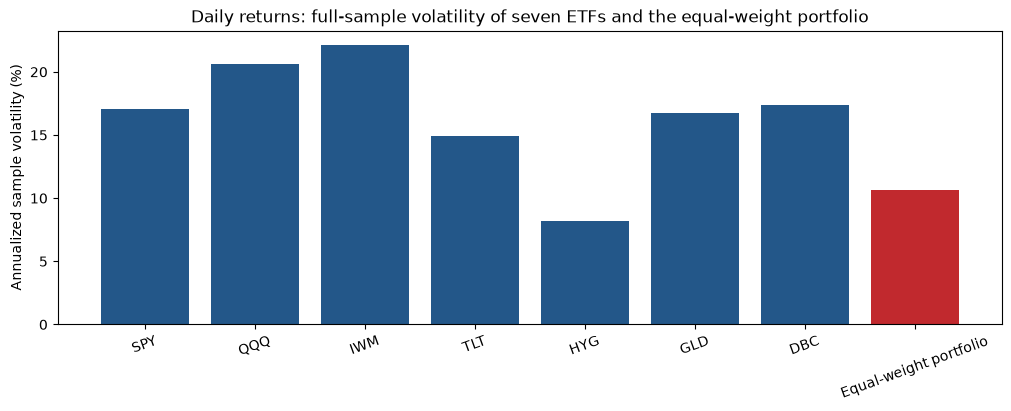

In [2]:
overview = pd.DataFrame({'observations': returns.count(), 'mean_daily_return': returns.mean(),
                         'annualized_volatility': returns.std(ddof=1)*np.sqrt(252),
                         'zero_returns': returns.eq(0).sum(), 'negative_returns': returns.lt(0).sum()})
overview['start_date'] = str(returns.index.min().date())
overview['end_date'] = str(returns.index.max().date())
overview.to_csv(TABLE_DIR / 'asset_portfolio_overview.csv', index_label='asset')
display(overview)
fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
ax.bar(overview.index, overview.annualized_volatility*100, color=['#235789']*7+['#c1292e'])
ax.set_ylabel('Annualized sample volatility (%)')
ax.set_title('Daily returns: full-sample volatility of seven ETFs and the equal-weight portfolio')
ax.tick_params(axis='x', rotation=20)
fig.savefig(FIGURE_DIR / 'asset_portfolio_volatility.png', dpi=160)
if plt.get_backend().lower() != 'agg':
    plt.show()
plt.close(fig)

## Validation and test errors

The validation comparison includes all five model families. Each tree model's reported
row is its best validation specification. The test table deliberately leaves unselected
ML models unevaluated. Units below are annualized volatility decimals, not percentages
of forecast accuracy. No claim of statistical superiority is made from point errors alone.

,model,MAE_validation,RMSE_validation,MAE_test,RMSE_test,test_status
0,Linear Regression,0.035279,0.057393,0.036341,0.052714,evaluated
1,XGBoost,0.035301,0.060218,NaN,NaN,not evaluated: not selected on validation
2,EWMA,0.041399,0.061941,0.039416,0.057162,evaluated
3,Random Forest,0.036301,0.063280,NaN,NaN,not evaluated: not selected on validation
4,Historical Volatility,0.041307,0.063688,0.040831,0.060382,evaluated


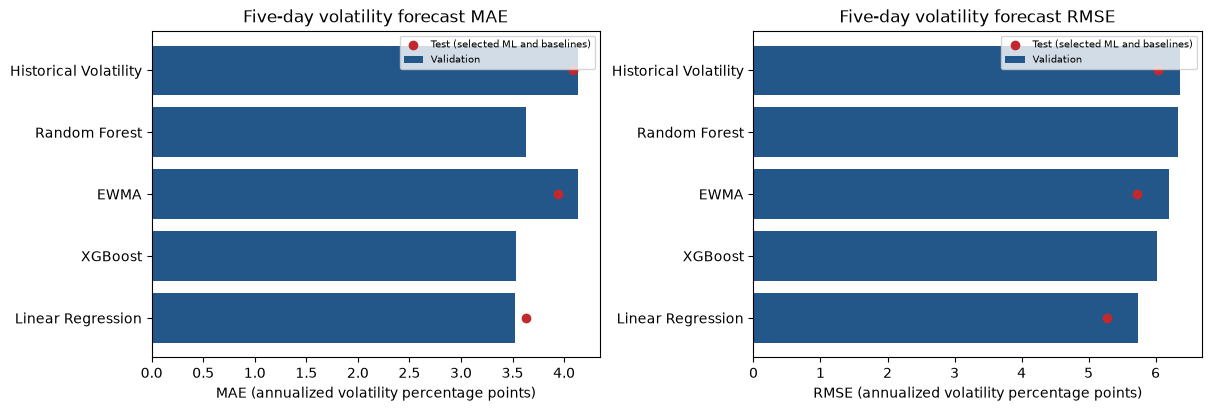

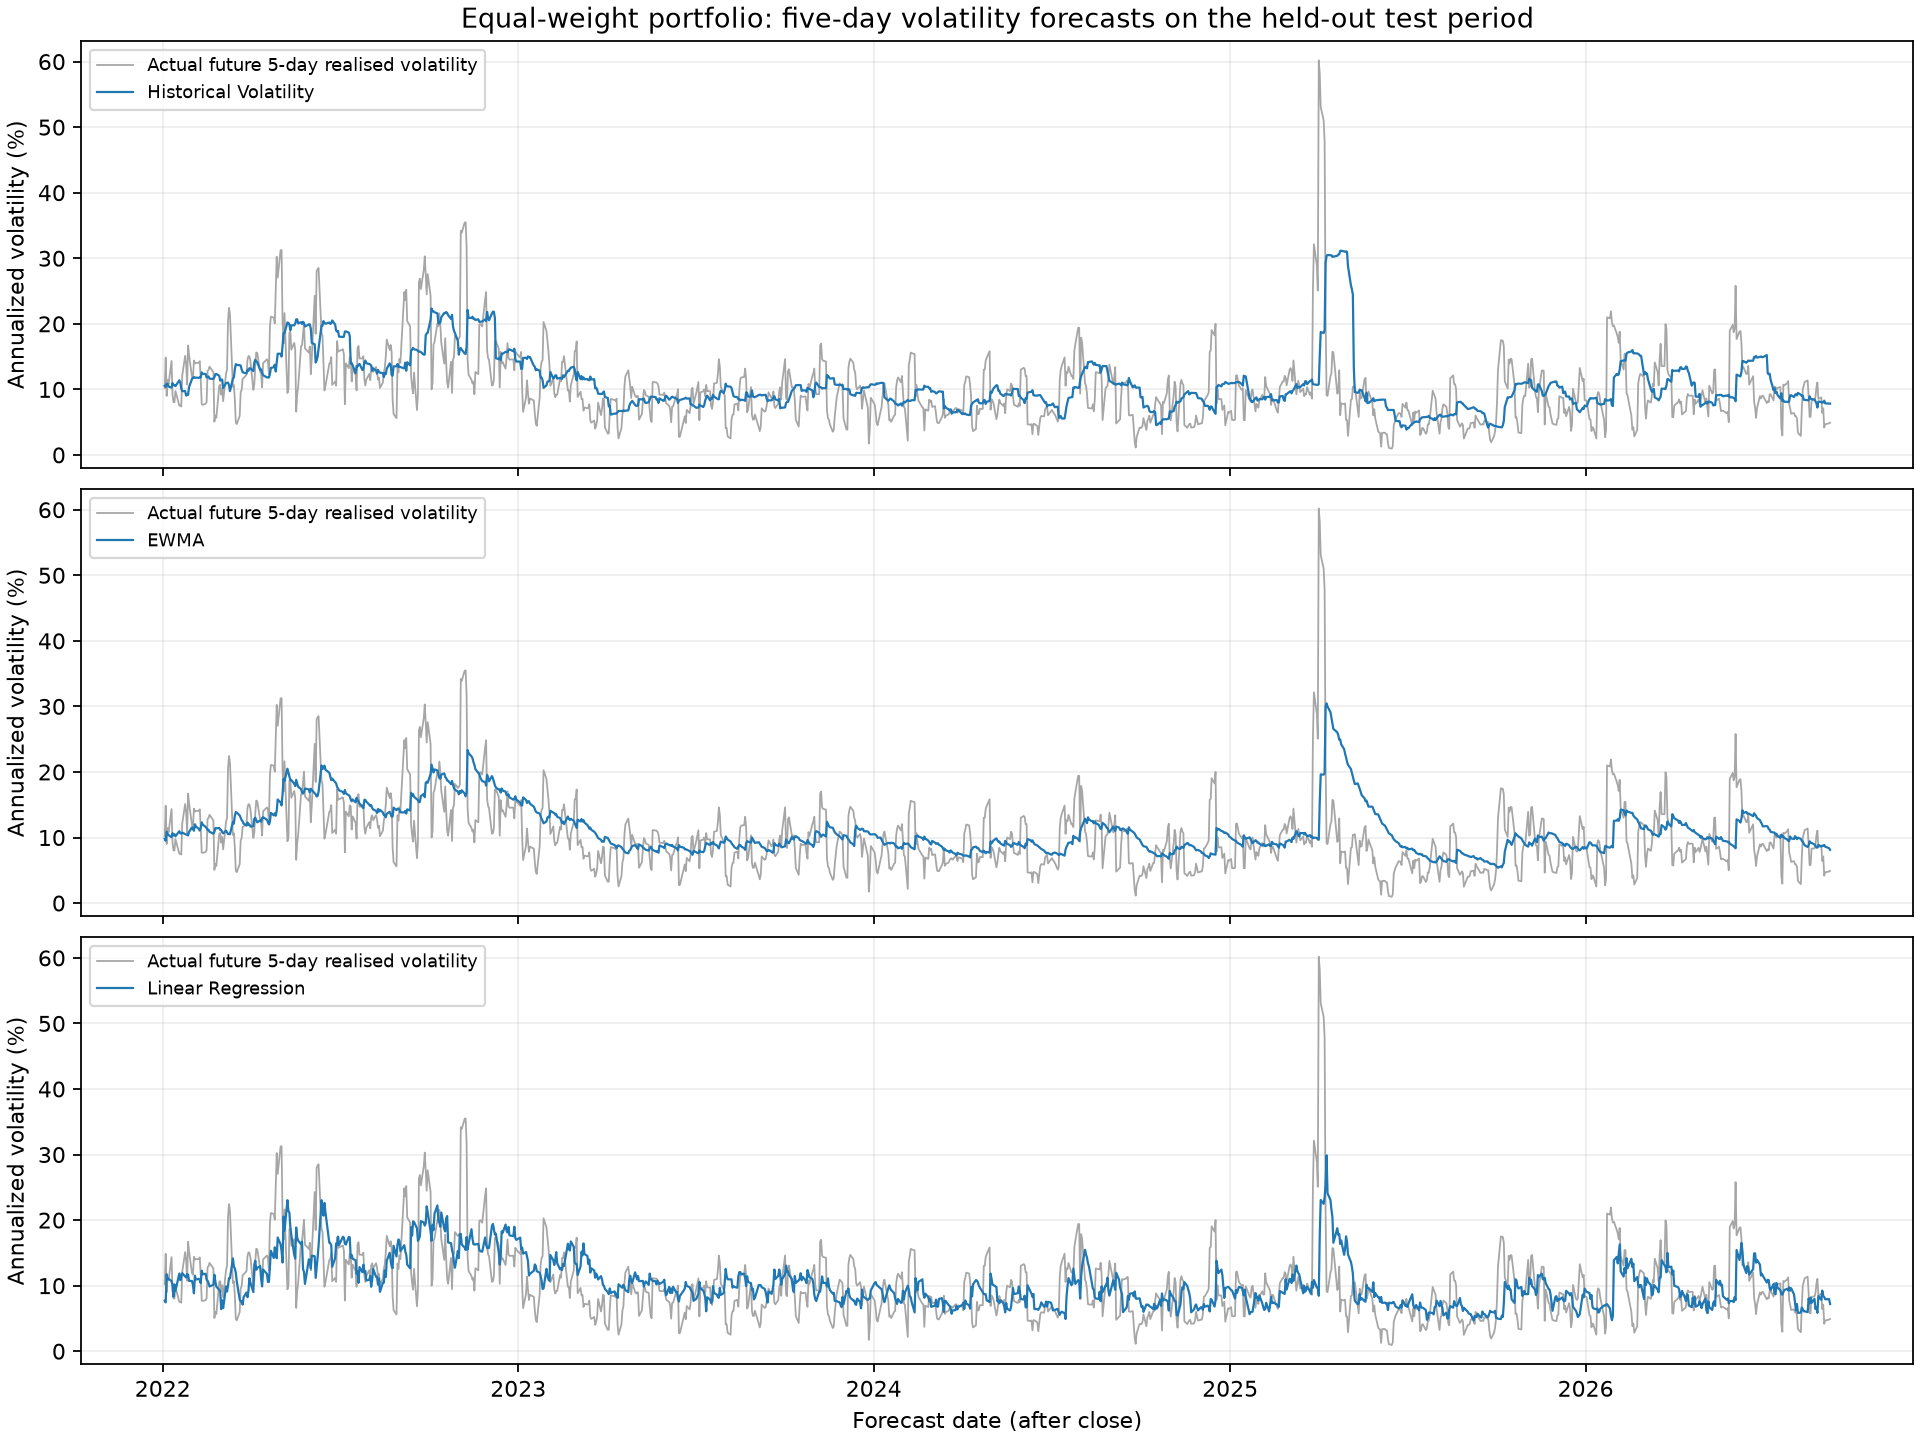

In [3]:
comparison = validation[['model', 'MAE', 'RMSE']].merge(test, on='model', how='left', suffixes=('_validation', '_test'))
comparison['test_status'] = np.where(comparison.MAE_test.notna(), 'evaluated', 'not evaluated: not selected on validation')
comparison.to_csv(TABLE_DIR / 'model_comparison.csv', index=False)
display(comparison)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for ax, metric in zip(axes, ['MAE', 'RMSE']):
    ax.barh(comparison.model, comparison[f'{metric}_validation']*100, color='#235789', label='Validation')
    ax.scatter(comparison[f'{metric}_test']*100, comparison.model, color='#c1292e', label='Test (selected ML and baselines)', zorder=3)
    ax.set_xlabel(f'{metric} (annualized volatility percentage points)')
    ax.set_title(f'Five-day volatility forecast {metric}')
    ax.legend(fontsize=7)
fig.savefig(FIGURE_DIR / 'model_errors.png', dpi=160)
if plt.get_backend().lower() != 'agg':
    plt.show()
plt.close(fig)
display(Image(filename=str(FIGURE_DIR / 'test_volatility_forecasts.png')))

## Five-day risk calibration

The following tests use non-overlapping future five-session return windows. The p-values
refer to unconditional violation frequency, not independence, ES calibration or profit.
Multiple models/confidence levels are inspected without a multiple-testing adjustment;
treat these as exploratory diagnostics. Few expected 99% violations make inference imprecise.

,model,confidence,observations,violations,violation_rate,expected_rate,expected_violations,kupiec_statistic,kupiec_p_value,exact_binomial_p_value,rate_ci_low,rate_ci_high
0,Historical Volatility,0.95,235,10,0.042553,0.05,11.75,0.288319,0.591300,0.763756,0.020592,0.076863
1,Historical Volatility,0.99,235,3,0.012766,0.01,2.35,0.166999,0.682792,0.511885,0.002640,0.036852
2,EWMA,0.95,235,8,0.034043,0.05,11.75,1.412053,0.234716,0.366086,0.014810,0.065973
3,EWMA,0.99,235,1,0.004255,0.01,2.35,0.998988,0.317556,0.735604,0.000108,0.023480
4,Linear Regression,0.95,235,13,0.055319,0.05,11.75,0.135511,0.712785,0.653063,0.029780,0.092740
5,Linear Regression,0.99,235,4,0.017021,0.01,2.35,0.966762,0.325489,0.304464,0.004657,0.043005


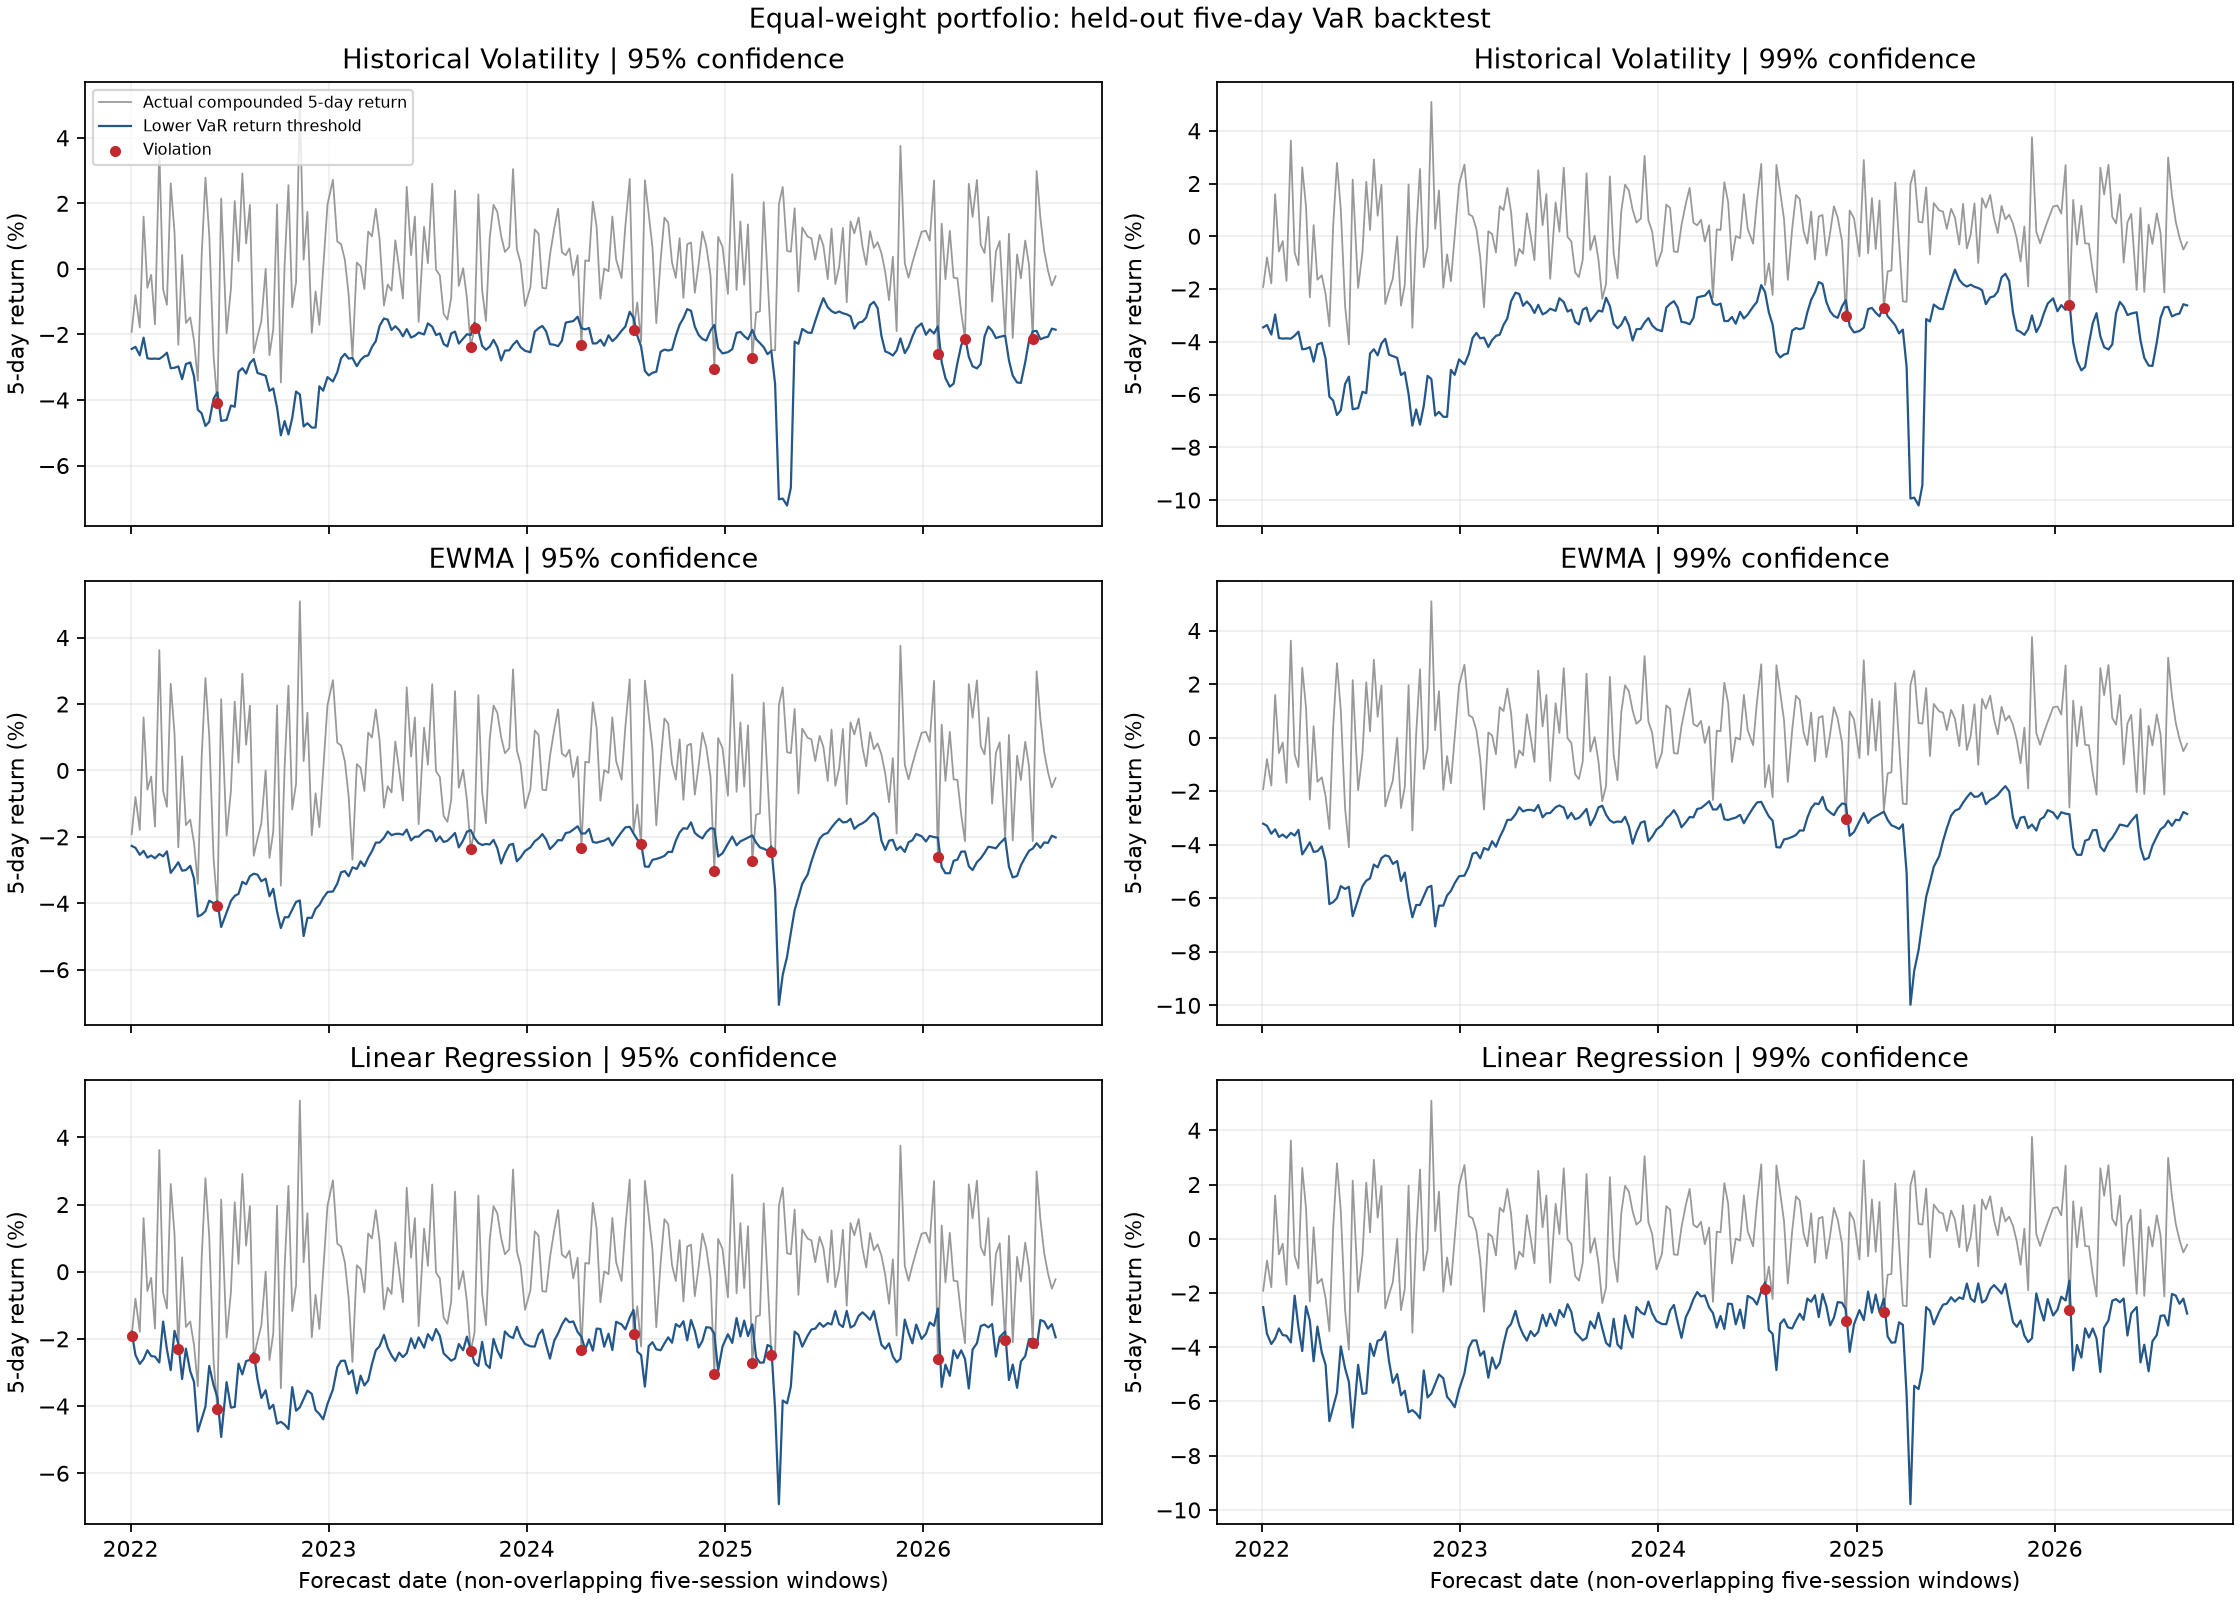

The validation-selected ML model was Linear Regression; the overall validation winner was Linear Regression.

On the held-out test period, Linear Regression had MAE 0.036341 and RMSE 0.052714 in annualized volatility units.

Its test RMSE was 7.78% lower than the lower-error baseline (EWMA). This is a descriptive comparison, not a significance test.

Historical Volatility at 95%: 10/235 violations (4.26%); Kupiec p=0.5913.

Historical Volatility at 99%: 3/235 violations (1.28%); Kupiec p=0.6828.

EWMA at 95%: 8/235 violations (3.40%); Kupiec p=0.2347.

EWMA at 99%: 1/235 violations (0.43%); Kupiec p=0.3176.

Linear Regression at 95%: 13/235 violations (5.53%); Kupiec p=0.7128.

Linear Regression at 99%: 4/235 violations (1.70%); Kupiec p=0.3255.

In [4]:
display(backtests)
display(Image(filename=str(FIGURE_DIR / 'var_violations.png')))
selected_name = selection['selected_ml_model']
selected_test = test.set_index('model').loc[selected_name]
best_baseline = test.loc[test.model.isin(['Historical Volatility', 'EWMA'])].sort_values('RMSE').iloc[0]
relative_rmse = (selected_test.RMSE / best_baseline.RMSE - 1)*100
direction = 'higher' if relative_rmse >= 0 else 'lower'
findings = [
    f"The validation-selected ML model was {selected_name}; the overall validation winner was {selection['overall_validation_winner']}.",
    f"On the held-out test period, {selected_name} had MAE {selected_test.MAE:.6f} and RMSE {selected_test.RMSE:.6f} in annualized volatility units.",
    f"Its test RMSE was {abs(relative_rmse):.2f}% {direction} than the lower-error baseline ({best_baseline['model']}). This is a descriptive comparison, not a significance test.",
]
for _, row in backtests.iterrows():
    findings.append(f"{row['model']} at {row.confidence:.0%}: {int(row.violations)}/{int(row.observations)} violations ({row.violation_rate:.2%}); Kupiec p={row.kupiec_p_value:.4f}.")
findings_text = '\n\n'.join(findings)
(TABLE_DIR / 'findings.md').write_text(findings_text, encoding='utf-8')
display(Markdown(findings_text))

## What this study can and cannot show

Five observations give a noisy volatility target. The test period covers one historical
sequence, and model rankings may change with another period. The small validation search
is transparent but not an exhaustive model comparison. No trading or economic-value claim
follows from lower RMSE. Non-overlapping windows remove shared returns, not all dependence.

Normal VaR can underestimate heavy-tailed losses. The square-root-of-time conversion
assumes no conditional serial correlation and treats compound returns approximately.
ES is a model-implied estimate here, without a dedicated ES backtest. Zero drift ignores
the conditional mean. Daily equal-weight rebalancing ignores transaction costs and liquidity.
Adjusted Yahoo prices are a historical vintage, not a point-in-time archive; public reruns
may change if the provider revises prices. Seven chosen ETFs also limit generalization.

Useful next steps would be a prespecified expanding-window evaluation with purging,
Student-t or filtered-historical tail models, conditional coverage and dedicated ES tests,
and explicit rebalancing costs. These are future work, not results claimed in this project.

In [5]:
summary = dict(selected_ml_model=selected_name, test_rmse=float(selected_test.RMSE),
               test_mae=float(selected_test.MAE), best_baseline=best_baseline['model'],
               relative_rmse_percent=float(relative_rmse), main_backtest_windows=int(backtests.observations.iloc[0]),
               figures=['asset_portfolio_volatility.png', 'model_errors.png', 'test_volatility_forecasts.png', 'var_violations.png'])
(TABLE_DIR / 'results_summary.json').write_text(json.dumps(summary, indent=2))
for figure in summary['figures']:
    assert (FIGURE_DIR / figure).is_file()
print('Part 5 completed: tables, figures and discussion use the executed results.')

Part 5 completed: tables, figures and discussion use the executed results.
